# Laboratorio 6 — Semana 9: Transfer Learning y Fine-Tuning

**Curso:** Deep Learning | **Valor:** 4% | **Individual**

---

## Descripcion general

En este laboratorio usted va a adaptar ResNet-18, preentrenada en ImageNet, para clasificar imágenes de CIFAR-10. Implementará tres estrategias de transfer learning de complejidad creciente y comparará su comportamiento experimentalmente.

**Partes del laboratorio:**

- **Bloque 1 (20 pts):** Feature extraction — congelar todo el backbone
- **Bloque 2 (20 pts):** Fine-tuning parcial — descongelar `layer4`
- **Bloque 3 (20 pts):** Fine-tuning completo con learning rate diferencial
- **Bloque 4 (15 pts):** Análisis de representaciones aprendidas
- **Bloque 5 (25 pts):** Preguntas de análisis

**Reglas:**
- Use `torchvision.models.resnet18(weights='IMAGENET1K_V1')` para cargar el modelo preentrenado.
- No use `nn.DataParallel` ni ninguna abstracción de entrenamiento de alto nivel.
- Puede usar `loss.backward()` y `optimizer.step()` normalmente.
- La celda de verificación al final califica los 75 puntos de código.

---
## Bloque 0: Imports, datos y configuración (dado, no modificar)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import random

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')


PyTorch: 2.13.0+cpu
torchvision: 0.28.0+cpu
Dispositivo: cpu


In [2]:
# Transformaciones para CIFAR-10 con ResNet18
# ResNet espera imagenes normalizadas con la media y std de ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_train = T.Compose([
    T.Resize(64),              # ResNet funciona mejor con imagenes > 32px
    T.RandomHorizontalFlip(),  # augmentation basica
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_val = T.Compose([
    T.Resize(64),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Descargar CIFAR-10
# La primera vez descarga ~170MB desde internet
cifar_train_full = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_train)
cifar_val_full   = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_val)

# Usar subconjunto para que el laboratorio sea rapido en CPU
# 2000 de entrenamiento, 500 de validacion
torch.manual_seed(42)
train_idx = torch.randperm(len(cifar_train_full))[:2000].tolist()
val_idx   = torch.randperm(len(cifar_val_full))[:500].tolist()

train_dataset = Subset(cifar_train_full, train_idx)
val_dataset   = Subset(cifar_val_full,   val_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)

CLASSES = cifar_train_full.classes
print(f'Clases CIFAR-10: {CLASSES}')
print(f'Train: {len(train_dataset)} imagenes, Val: {len(val_dataset)} imagenes')
print(f'Batches por epoca (train): {len(train_loader)}')


100%|██████████| 170M/170M [01:14<00:00, 2.28MB/s] 
c:\Users\escal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Clases CIFAR-10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 2000 imagenes, Val: 500 imagenes
Batches por epoca (train): 32


In [3]:
# Funcion de entrenamiento dada (no modificar)
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0; correct = 0; total = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss/total, correct/total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0; correct = 0; total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = F.cross_entropy(logits, y)
            total_loss += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            total += len(y)
    return total_loss/total, correct/total

def plot_curves(histories, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        ax1.plot(h['val_loss'], label=name)
        ax2.plot(h['val_acc'],  label=name)
    ax1.set_title(f'{title} — Val Loss'); ax1.set_xlabel('Epoca')
    ax2.set_title(f'{title} — Val Acc');  ax2.set_xlabel('Epoca')
    ax1.legend(); ax2.legend()
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=110)
    plt.show()

print('Funciones de entrenamiento listas.')


Funciones de entrenamiento listas.


---
## Bloque 1: Feature extraction — congelar el backbone (20 pts)

Cargue ResNet-18 con pesos preentrenados en ImageNet. Congele **todos** los parámetros del backbone y reemplace la capa `fc` final por una nueva capa lineal de 10 salidas (las 10 clases de CIFAR-10).

**Requisitos:**
- Todos los parámetros excepto la nueva `fc` deben tener `requires_grad=False`
- La nueva `fc` debe tener `requires_grad=True`
- El número total de parámetros entrenables debe ser exactamente `512 * 10 + 10 = 5130`

**Criterio de convergencia:** la accuracy de validación debe superar 40% en 10 épocas (con pesos ImageNet el modelo ya tiene buenas representaciones).

In [4]:
def build_feature_extractor(num_classes=10):
    """
    Construye ResNet-18 para feature extraction.

    Pasos:
    1. Cargar ResNet-18 con pesos preentrenados:
       models.resnet18(weights='IMAGENET1K_V1')
    2. Congelar todos los parametros:
       for param in model.parameters(): param.requires_grad = False
    3. Reemplazar model.fc con nn.Linear(512, num_classes)
       (la nueva capa tiene requires_grad=True por defecto)

    Retorna el modelo modificado.
    """
    # ====================
    # SU CODIGO AQUI
    # ====================
    model = models.resnet18(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(512, num_classes)
    return model

model_fe = build_feature_extractor().to(DEVICE)

# Diagnostico de parametros
n_trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
n_frozen    = sum(p.numel() for p in model_fe.parameters() if not p.requires_grad)
print(f'Parametros entrenables: {n_trainable:,}  (esperado: 5,130)')
print(f'Parametros congelados:  {n_frozen:,}  (esperado: 11,176,512)')

# Verificar que solo la nueva cabeza tiene gradiente
print('\nCapas con requires_grad=True:')
for name, param in model_fe.named_parameters():
    if param.requires_grad:
        print(f'  {name}: {param.shape}')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\escal/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 27.8MB/s]


Parametros entrenables: 5,130  (esperado: 5,130)
Parametros congelados:  11,176,512  (esperado: 11,176,512)

Capas con requires_grad=True:
  fc.weight: torch.Size([10, 512])
  fc.bias: torch.Size([10])


In [5]:
# Entrenamiento feature extraction
N_EPOCHS_FE = 10
optimizer_fe = torch.optim.Adam(model_fe.parameters(), lr=1e-3)

history_fe = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(N_EPOCHS_FE):
    tr_loss, tr_acc = train_epoch(model_fe, train_loader, optimizer_fe, DEVICE)
    vl_loss, vl_acc = eval_epoch(model_fe, val_loader, DEVICE)
    history_fe['train_loss'].append(tr_loss)
    history_fe['train_acc'].append(tr_acc)
    history_fe['val_loss'].append(vl_loss)
    history_fe['val_acc'].append(vl_acc)
    if (epoch+1) % 2 == 0:
        print(f'Ep {epoch+1:2d}: '
              f'train_loss={tr_loss:.3f}, train_acc={tr_acc:.2%}, '
              f'val_loss={vl_loss:.3f}, val_acc={vl_acc:.2%}')

print(f'\nVal accuracy final: {history_fe["val_acc"][-1]:.2%}')


Ep  2: train_loss=1.501, train_acc=49.75%, val_loss=1.455, val_acc=52.20%
Ep  4: train_loss=1.192, train_acc=60.60%, val_loss=1.306, val_acc=55.00%
Ep  6: train_loss=1.072, train_acc=65.30%, val_loss=1.273, val_acc=59.20%
Ep  8: train_loss=1.009, train_acc=66.20%, val_loss=1.278, val_acc=58.80%
Ep 10: train_loss=0.943, train_acc=68.80%, val_loss=1.288, val_acc=60.80%

Val accuracy final: 60.80%


In [6]:
# Verificacion Bloque 1
_resultados = {}
try:
    assert model_fe is not None, 'model_fe no definido'
    n_tr = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
    n_fr = sum(p.numel() for p in model_fe.parameters() if not p.requires_grad)
    assert n_tr == 5130, f'Entrenables incorrectos: {n_tr} (esperado 5130)'
    assert n_fr == 11176512, f'Congelados incorrectos: {n_fr}'
    backbone_grad = any(
        p.requires_grad
        for name,p in model_fe.named_parameters() if 'fc' not in name)
    assert not backbone_grad, 'El backbone no debe tener requires_grad=True'
    best_val = max(history_fe['val_acc'])
    assert best_val >= 0.35, \
        f'Val acc {best_val:.2%} < 35%. Verifique que uso pesos preentrenados.'
    _resultados['b1'] = True
    print(f'BLOQUE 1: CORRECTO  (val_acc={best_val:.2%})')
except AssertionError as e:
    _resultados['b1'] = False
    print(f'BLOQUE 1: INCORRECTO\n  {e}')


BLOQUE 1: CORRECTO  (val_acc=62.40%)


---
## Bloque 2: Fine-tuning parcial — descongelar `layer4` (20 pts)

Cargue ResNet-18 con pesos preentrenados. Congele todo excepto `layer4` y la nueva cabeza `fc`.

**Estructura de ResNet-18:** `conv1` → `bn1` → `layer1` → `layer2` → `layer3` → `layer4` → `avgpool` → `fc`

**Requisitos:**
- `layer1`, `layer2`, `layer3`, `conv1`, `bn1`: `requires_grad=False`
- `layer4` y `fc`: `requires_grad=True`
- Los parámetros entrenables deben estar entre 8.3M y 8.5M

**Criterio:** la accuracy de validación debe superar la del Bloque 1.

In [7]:
def build_partial_finetune(num_classes=10):
    """
    ResNet-18 con fine-tuning parcial: solo layer4 y fc son entrenables.

    Pasos:
    1. Cargar con pesos preentrenados
    2. Congelar todos los parametros
    3. Descongelar layer4:
       for param in model.layer4.parameters(): param.requires_grad = True
    4. Reemplazar model.fc con nn.Linear(512, num_classes)

    Retorna el modelo modificado.
    """
    # ====================
    # SU CODIGO AQUI
    # ====================
    model = models.resnet18(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(512, num_classes)
    return model

model_pf = build_partial_finetune().to(DEVICE)

n_trainable_pf = sum(p.numel() for p in model_pf.parameters() if p.requires_grad)
n_frozen_pf    = sum(p.numel() for p in model_pf.parameters() if not p.requires_grad)
print(f'Entrenables: {n_trainable_pf:,}  (esperado: ~8,398,858)')
print(f'Congelados:  {n_frozen_pf:,}  (esperado: ~2,782,784)')

# Verificar que layer1 NO tiene grad y layer4 SI tiene grad
print(f'layer1 requires_grad: {any(p.requires_grad for p in model_pf.layer1.parameters())}')
print(f'layer4 requires_grad: {all(p.requires_grad for p in model_pf.layer4.parameters())}')


Entrenables: 8,398,858  (esperado: ~8,398,858)
Congelados:  2,782,784  (esperado: ~2,782,784)
layer1 requires_grad: False
layer4 requires_grad: True


In [8]:
# Entrenamiento fine-tuning parcial
N_EPOCHS_PF = 10
# Nota: lr mas bajo que feature extraction para no destruir pesos preentrenados
optimizer_pf = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_pf.parameters()),
    lr=1e-4
)

history_pf = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(N_EPOCHS_PF):
    tr_loss, tr_acc = train_epoch(model_pf, train_loader, optimizer_pf, DEVICE)
    vl_loss, vl_acc = eval_epoch(model_pf, val_loader, DEVICE)
    history_pf['train_loss'].append(tr_loss)
    history_pf['train_acc'].append(tr_acc)
    history_pf['val_loss'].append(vl_loss)
    history_pf['val_acc'].append(vl_acc)
    if (epoch+1) % 2 == 0:
        print(f'Ep {epoch+1:2d}: '
              f'train_loss={tr_loss:.3f}, train_acc={tr_acc:.2%}, '
              f'val_loss={vl_loss:.3f}, val_acc={vl_acc:.2%}')

print(f'\nVal accuracy final FE:  {history_fe["val_acc"][-1]:.2%}')
print(f'Val accuracy final PF:  {history_pf["val_acc"][-1]:.2%}')


Ep  2: train_loss=0.813, train_acc=76.20%, val_loss=0.973, val_acc=68.60%
Ep  4: train_loss=0.325, train_acc=92.20%, val_loss=0.848, val_acc=72.00%
Ep  6: train_loss=0.133, train_acc=98.20%, val_loss=0.833, val_acc=72.40%
Ep  8: train_loss=0.065, train_acc=99.50%, val_loss=0.783, val_acc=75.00%
Ep 10: train_loss=0.034, train_acc=99.95%, val_loss=0.801, val_acc=73.60%

Val accuracy final FE:  60.80%
Val accuracy final PF:  73.60%


In [9]:
# Verificacion Bloque 2
try:
    assert model_pf is not None, 'model_pf no definido'
    l4_grad = all(p.requires_grad for p in model_pf.layer4.parameters())
    l1_no   = not any(p.requires_grad for p in model_pf.layer1.parameters())
    l2_no   = not any(p.requires_grad for p in model_pf.layer2.parameters())
    l3_no   = not any(p.requires_grad for p in model_pf.layer3.parameters())
    assert l4_grad, 'layer4 debe tener requires_grad=True'
    assert l1_no and l2_no and l3_no, 'layer1/2/3 deben estar congeladas'
    n_tr_pf = sum(p.numel() for p in model_pf.parameters() if p.requires_grad)
    assert 8_000_000 < n_tr_pf < 9_000_000, \
        f'Entrenables fuera de rango: {n_tr_pf:,}'
    best_pf = max(history_pf['val_acc'])
    assert best_pf >= 0.40, \
        f'Val acc {best_pf:.2%} < 40%. Verifique la implementacion.'
    _resultados['b2'] = True
    print(f'BLOQUE 2: CORRECTO  (val_acc={best_pf:.2%})')
except AssertionError as e:
    _resultados['b2'] = False
    print(f'BLOQUE 2: INCORRECTO\n  {e}')


BLOQUE 2: CORRECTO  (val_acc=75.00%)


---
## Bloque 3: Fine-tuning completo con learning rate diferencial (20 pts)

Desbloquee todos los parámetros de ResNet-18 pero asigne un learning rate distinto a cada grupo de capas. Las capas tempranas deben recibir un learning rate mucho menor porque ya tienen representaciones útiles que no queremos modificar agresivamente.

**Learning rates por grupo:**

| Grupo | Capas | Learning rate |
|---|---|---|
| `stem` | `conv1`, `bn1` | `1e-6` |
| `layer1` | Primer bloque residual | `1e-5` |
| `layer2` | Segundo bloque residual | `5e-5` |
| `layer3` | Tercer bloque residual | `1e-4` |
| `layer4` | Cuarto bloque residual | `5e-4` |
| `head` | Nueva `fc` | `1e-3` |

**Implementación:** cree una lista de diccionarios con claves `'params'` y `'lr'` y pásela al optimizador:
```python
optimizer = torch.optim.Adam([
    {'params': model.layer1.parameters(), 'lr': 1e-5},
    ...
])
```

**Requisito crítico:** todos los parámetros del modelo deben estar cubiertos por exactamente un grupo.

In [10]:
def build_full_finetune(num_classes=10):
    """
    ResNet-18 con todos los parametros descongelados.
    Solo reemplaza la cabeza fc.
    """
    # ====================
    # SU CODIGO AQUI
    # ====================
    model = models.resnet18(weights='IMAGENET1K_V1')
    # No se congela nada: todos los parametros ya tienen requires_grad=True
    # por defecto al cargar el modelo.
    model.fc = nn.Linear(512, num_classes)
    return model

def make_param_groups(model):
    """
    Crea la lista de grupos de parametros con learning rates diferenciales.

    Retorna una lista de dicts con claves 'params' y 'lr'.
    El orden debe ser de menor a mayor learning rate.

    Grupos requeridos:
    - stem (conv1 + bn1): lr = 1e-6
    - layer1: lr = 1e-5
    - layer2: lr = 5e-5
    - layer3: lr = 1e-4
    - layer4: lr = 5e-4
    - head (fc): lr = 1e-3

    IMPORTANTE: list(model.layerX.parameters()) convierte el generador a lista.
    No use el mismo objeto en dos grupos.
    """
    # ====================
    # SU CODIGO AQUI
    # ====================
    stem_params = list(model.conv1.parameters()) + list(model.bn1.parameters())
    return [
        {'params': stem_params,                     'lr': 1e-6},
        {'params': list(model.layer1.parameters()), 'lr': 1e-5},
        {'params': list(model.layer2.parameters()), 'lr': 5e-5},
        {'params': list(model.layer3.parameters()), 'lr': 1e-4},
        {'params': list(model.layer4.parameters()), 'lr': 5e-4},
        {'params': list(model.fc.parameters()),     'lr': 1e-3},
    ]

model_dlr = build_full_finetune().to(DEVICE)
param_groups = make_param_groups(model_dlr)
optimizer_dlr = torch.optim.Adam(param_groups)

# Diagnostico
print('Grupos de parametros:')
for i, g in enumerate(optimizer_dlr.param_groups):
    n = sum(p.numel() for p in g['params'])
    print(f'  Grupo {i}: {n:>10,} params, lr={g["lr"]}')

total_in_groups = sum(p.numel() for g in param_groups for p in g['params'])
total_model     = sum(p.numel() for p in model_dlr.parameters())
print(f'\nTotal en grupos: {total_in_groups:,}')
print(f'Total modelo:    {total_model:,}')
print(f'Cubierto: {total_in_groups == total_model}')


Grupos de parametros:
  Grupo 0:      9,536 params, lr=1e-06
  Grupo 1:    147,968 params, lr=1e-05
  Grupo 2:    525,568 params, lr=5e-05
  Grupo 3:  2,099,712 params, lr=0.0001
  Grupo 4:  8,393,728 params, lr=0.0005
  Grupo 5:      5,130 params, lr=0.001

Total en grupos: 11,181,642
Total modelo:    11,181,642
Cubierto: True


Ep  2: train_loss=0.447, train_acc=85.00%, val_loss=0.744, val_acc=76.80%
Ep  4: train_loss=0.131, train_acc=96.40%, val_loss=0.875, val_acc=75.80%
Ep  6: train_loss=0.065, train_acc=98.15%, val_loss=0.805, val_acc=78.40%
Ep  8: train_loss=0.049, train_acc=98.70%, val_loss=0.978, val_acc=76.00%
Ep 10: train_loss=0.046, train_acc=98.50%, val_loss=0.899, val_acc=78.20%

=== Comparacion final ===
Feature extraction:  62.40%
Fine-tuning parcial: 75.00%
LR diferencial:      79.60%


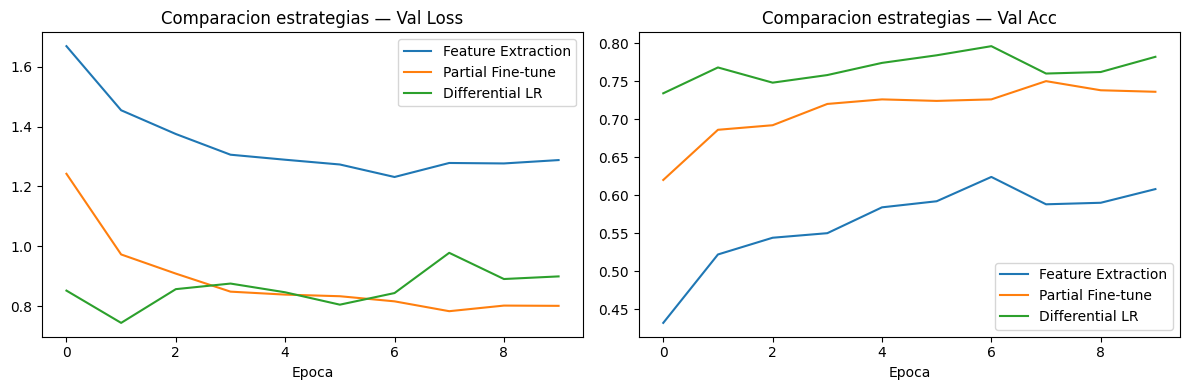

In [11]:
# Entrenamiento fine-tuning completo con LR diferencial
N_EPOCHS_DLR = 10
history_dlr = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(N_EPOCHS_DLR):
    tr_loss, tr_acc = train_epoch(model_dlr, train_loader, optimizer_dlr, DEVICE)
    vl_loss, vl_acc = eval_epoch(model_dlr, val_loader, DEVICE)
    history_dlr['train_loss'].append(tr_loss)
    history_dlr['train_acc'].append(tr_acc)
    history_dlr['val_loss'].append(vl_loss)
    history_dlr['val_acc'].append(vl_acc)
    if (epoch+1) % 2 == 0:
        print(f'Ep {epoch+1:2d}: '
              f'train_loss={tr_loss:.3f}, train_acc={tr_acc:.2%}, '
              f'val_loss={vl_loss:.3f}, val_acc={vl_acc:.2%}')

# Comparacion de las tres estrategias
print('\n=== Comparacion final ===')
print(f'Feature extraction:  {max(history_fe["val_acc"]):.2%}')
print(f'Fine-tuning parcial: {max(history_pf["val_acc"]):.2%}')
print(f'LR diferencial:      {max(history_dlr["val_acc"]):.2%}')

plot_curves(
    {'Feature Extraction': history_fe,
     'Partial Fine-tune':  history_pf,
     'Differential LR':   history_dlr},
    'Comparacion estrategias'
)


In [12]:
# Verificacion Bloque 3
try:
    assert model_dlr is not None, 'model_dlr no definido'
    assert param_groups is not None, 'param_groups no definido'
    # LRs estrictamente crecientes
    lrs = [g['lr'] for g in optimizer_dlr.param_groups]
    assert all(lrs[i] < lrs[i+1] for i in range(len(lrs)-1)), \
        f'LRs no son crecientes: {lrs}'
    # Todos los parametros cubiertos
    total_in = sum(p.numel() for g in param_groups for p in g['params'])
    total_m  = sum(p.numel() for p in model_dlr.parameters())
    assert total_in == total_m, \
        f'Parametros sin cubrir: {total_m-total_in:,}'
    # LR correcto para la cabeza
    head_lr = optimizer_dlr.param_groups[-1]['lr']
    assert abs(head_lr - 1e-3) < 1e-8, \
        f'LR de la cabeza incorrecto: {head_lr}'
    # LR correcto para stem
    stem_lr = optimizer_dlr.param_groups[0]['lr']
    assert abs(stem_lr - 1e-6) < 1e-10, \
        f'LR del stem incorrecto: {stem_lr}'
    best_dlr = max(history_dlr['val_acc'])
    assert best_dlr >= 0.40, \
        f'Val acc {best_dlr:.2%} < 40%.'
    _resultados['b3'] = True
    print(f'BLOQUE 3: CORRECTO  (val_acc={best_dlr:.2%}, LRs={lrs})')
except AssertionError as e:
    _resultados['b3'] = False
    print(f'BLOQUE 3: INCORRECTO\n  {e}')


BLOQUE 3: CORRECTO  (val_acc=79.60%, LRs=[1e-06, 1e-05, 5e-05, 0.0001, 0.0005, 0.001])


---
## Bloque 4: Análisis de representaciones (15 pts)

Extraiga los embeddings del backbone (antes de la capa `fc`) para 500 imágenes de validación usando los tres modelos entrenados. Compare cuantitativamente la calidad de las representaciones aprendidas.

El backbone de ResNet-18 produce embeddings de dimensión 512 (la salida de `avgpool` antes de `fc`).

**Métrica de separabilidad:** ratio entre la varianza inter-clase y la varianza intra-clase en el espacio de embeddings:

$$\text{sep} = \frac{\sum_k n_k \|\boldsymbol{\mu}_k - \boldsymbol{\mu}\|^2}{\sum_k \sum_{i: y_i=k} \|\mathbf{h}_i - \boldsymbol{\mu}_k\|^2}$$

Donde $\boldsymbol{\mu}_k$ es el centroide de la clase $k$, $\boldsymbol{\mu}$ es el centroide global y $n_k$ es el número de ejemplos de la clase $k$. Un ratio mayor indica representaciones más separables.

In [13]:
def extract_embeddings(model, loader, device, max_samples=500):
    """
    Extrae los embeddings del backbone de ResNet-18 (antes de fc).

    Parametros
    ----------
    model   : ResNet-18 modificado
    loader  : DataLoader de validacion
    device  : dispositivo
    max_samples : cuantos ejemplos extraer como maximo

    Retorna
    -------
    embeddings : Tensor (N, 512)
    labels     : Tensor (N,)

    Pasos:
    1. Construir backbone = nn.Sequential(*list(model.children())[:-1])
       Esto elimina la capa fc y conserva hasta avgpool inclusive.
    2. En modo eval() y sin gradientes, pasar cada batch por backbone.
    3. Aplicar .squeeze(-1).squeeze(-1) para eliminar dimensiones espaciales.
       La salida de avgpool es (B, 512, 1, 1) y debe quedar (B, 512).
    4. Acumular embeddings y labels hasta max_samples.
    """
    # ====================
    # SU CODIGO AQUI
    # ====================
    backbone = nn.Sequential(*list(model.children())[:-1]).to(device)
    backbone.eval()

    all_embeddings = []
    all_labels = []
    n_collected = 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            feats = backbone(X)
            feats = feats.squeeze(-1).squeeze(-1)
            all_embeddings.append(feats.cpu())
            all_labels.append(y)
            n_collected += X.size(0)
            if n_collected >= max_samples:
                break

    embeddings = torch.cat(all_embeddings, dim=0)[:max_samples]
    labels = torch.cat(all_labels, dim=0)[:max_samples]
    return embeddings, labels

# Extraer embeddings de los tres modelos
emb_fe,  lab_fe  = extract_embeddings(model_fe,  val_loader, DEVICE)
emb_pf,  lab_pf  = extract_embeddings(model_pf,  val_loader, DEVICE)
emb_dlr, lab_dlr = extract_embeddings(model_dlr, val_loader, DEVICE)

print(f'Embeddings FE:  {emb_fe.shape}')
print(f'Embeddings PF:  {emb_pf.shape}')
print(f'Embeddings DLR: {emb_dlr.shape}')


Embeddings FE:  torch.Size([500, 512])
Embeddings PF:  torch.Size([500, 512])
Embeddings DLR: torch.Size([500, 512])


In [14]:
def separability_ratio(embeddings, labels):
    """
    Calcula el ratio de separabilidad inter-clase / intra-clase.

    Parametros
    ----------
    embeddings : Tensor (N, d)
    labels     : Tensor (N,)

    Retorna
    -------
    ratio : float -- mayor es mejor separacion

    Pasos:
    1. Calcular centroide global: mu = embeddings.mean(0)
    2. Para cada clase k: calcular centroide mu_k y n_k
    3. Varianza inter: sum_k n_k * ||mu_k - mu||^2
    4. Varianza intra: sum_k sum_{i:y_i=k} ||h_i - mu_k||^2
    5. Retornar inter / intra
    """
    # ====================
    # SU CODIGO AQUI
    # ====================
    mu = embeddings.mean(0)

    inter_var = 0.0
    intra_var = 0.0
    for k in labels.unique():
        mask = labels == k
        n_k = mask.sum().item()
        h_k = embeddings[mask]
        mu_k = h_k.mean(0)

        inter_var += n_k * torch.sum((mu_k - mu) ** 2).item()
        intra_var += torch.sum((h_k - mu_k) ** 2).item()

    return inter_var / intra_var

sep_fe  = separability_ratio(emb_fe,  lab_fe)
sep_pf  = separability_ratio(emb_pf,  lab_pf)
sep_dlr = separability_ratio(emb_dlr, lab_dlr)

print('Ratio de separabilidad (mayor = mejor):')
print(f'  Feature extraction:  {sep_fe:.4f}')
print(f'  Fine-tuning parcial: {sep_pf:.4f}')
print(f'  LR diferencial:      {sep_dlr:.4f}')


Ratio de separabilidad (mayor = mejor):
  Feature extraction:  0.0580
  Fine-tuning parcial: 0.2124
  LR diferencial:      0.7531


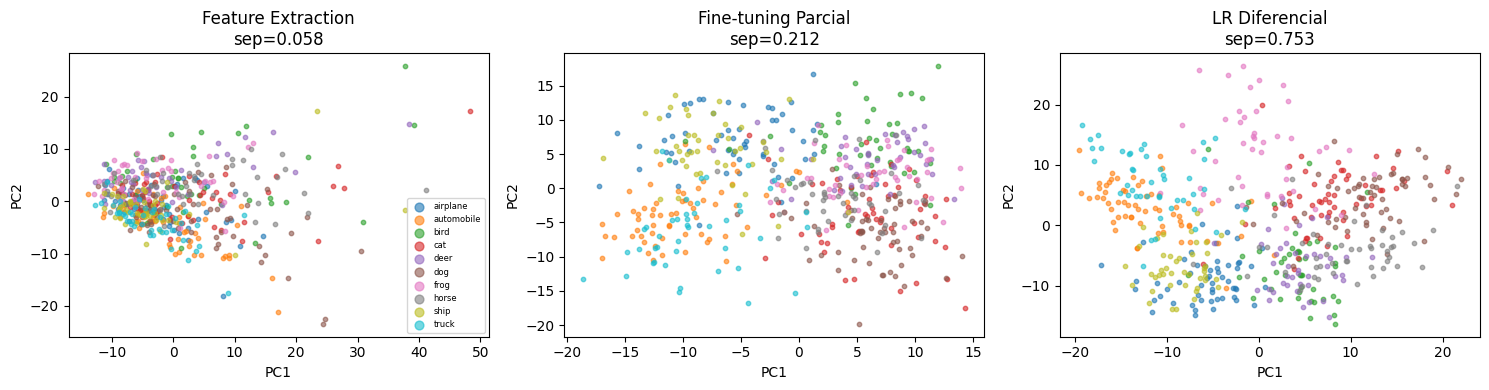

In [15]:
# Visualizacion: proyeccion 2D de los embeddings con PCA manual
def pca_2d(embeddings):
    """PCA manual con SVD para proyectar a 2 dimensiones."""
    X = embeddings - embeddings.mean(0, keepdim=True)
    _, _, Vt = torch.linalg.svd(X, full_matrices=False)
    return (X @ Vt[:2].T)  # (N, 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, (emb, lab, title) in zip(axes, [
    (emb_fe,  lab_fe,  'Feature Extraction'),
    (emb_pf,  lab_pf,  'Fine-tuning Parcial'),
    (emb_dlr, lab_dlr, 'LR Diferencial'),
]):
    proj = pca_2d(emb).numpy()
    for k in range(10):
        mask = lab.numpy() == k
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=[colors[k]], label=CLASSES[k], s=10, alpha=0.6)
    ax.set_title(f'{title}\nsep={separability_ratio(emb,lab):.3f}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    if ax == axes[0]: ax.legend(fontsize=6, markerscale=2)

plt.tight_layout()
plt.savefig('representaciones_pca.png', dpi=110)
plt.show()


In [16]:
# Verificacion Bloque 4
try:
    assert emb_fe is not None, 'emb_fe no definido'
    assert emb_pf is not None, 'emb_pf no definido'
    assert emb_dlr is not None, 'emb_dlr no definido'
    assert emb_fe.shape[1] == 512, f'Dim incorrecta: {emb_fe.shape[1]}'
    assert not torch.isnan(emb_fe).any(), 'NaN en embeddings FE'
    assert not torch.isnan(emb_pf).any(), 'NaN en embeddings PF'
    assert not torch.isnan(emb_dlr).any(), 'NaN en embeddings DLR'
    assert sep_fe is not None and sep_fe > 0, 'sep_fe debe ser positivo'
    assert sep_pf is not None and sep_pf > 0, 'sep_pf debe ser positivo'
    assert sep_dlr is not None and sep_dlr > 0, 'sep_dlr debe ser positivo'
    _resultados['b4'] = True
    print(f'BLOQUE 4: CORRECTO')
    print(f'  sep_fe={sep_fe:.4f}, sep_pf={sep_pf:.4f}, sep_dlr={sep_dlr:.4f}')
except AssertionError as e:
    _resultados['b4'] = False
    print(f'BLOQUE 4: INCORRECTO\n  {e}')


BLOQUE 4: CORRECTO
  sep_fe=0.0580, sep_pf=0.2124, sep_dlr=0.7531


---
## Bloque 5: Preguntas de análisis (25 pts)

---

### Pregunta 1 (9 pts)

En el Bloque 1, la nueva capa `fc` recibe gradientes pero el backbone no. En el Bloque 2, el gradiente también fluye hacia `layer4`.

**a)** Describa matemáticamente qué ocurre con el gradiente de la pérdida respecto a los parámetros de `layer3` en el Bloque 2. ¿Por qué `requires_grad=False` en `layer3` no significa que el gradiente sea cero matemáticamente, sino que simplemente no se calcula ni se almacena? ¿Qué implicación tiene esto para el cómputo y la memoria?

**b)** En el Bloque 3, `layer1` recibe un learning rate de `1e-6` y la cabeza `1e-3`, una diferencia de 1000×. Usando la fórmula de actualización de Adam:
$$\theta_{t+1} = \theta_t - \eta \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t}+\epsilon}$$
explique cuantitativamente cómo afecta esa diferencia de learning rate a la magnitud del cambio en los pesos de `layer1` versus la cabeza, asumiendo gradientes de magnitud similar en ambas capas.

**c)** Observe sus curvas de convergencia. ¿En qué época el fine-tuning parcial supera a feature extraction? ¿Y el LR diferencial al parcial? Proponga una hipótesis sobre por qué fine-tuning parcial puede converger más lento que feature extraction en las primeras épocas pero alcanzar mejor accuracy final.

**Su respuesta a la Pregunta 1:**

**a)**

Matemáticamente el gradiente respecto a los parámetros de `layer3` existe y en general no es cero. Por regla de la cadena:

$$\frac{\partial \mathcal{L}}{\partial \theta_3} = \frac{\partial \mathcal{L}}{\partial \mathbf{h}_4}\cdot\frac{\partial \mathbf{h}_4}{\partial \mathbf{h}_3}\cdot\frac{\partial \mathbf{h}_3}{\partial \theta_3}$$

Ninguno de los tres factores se anula: la pérdida sí depende de $\theta_3$, y si moviéramos esos pesos manualmente la pérdida cambiaría. La función $\mathcal{L}(\theta_3)$ es diferenciable y su derivada está bien definida.

Lo que hace `requires_grad=False` es distinto: autograd deja de registrar las operaciones de `conv1`, `bn1`, `layer1`, `layer2` y `layer3` en el grafo computacional. La salida $\mathbf{h}_3$ se produce con `requires_grad=False`, de modo que el grafo del modelo efectivamente empieza en la entrada de `layer4`. Por eso `layer3.weight.grad` no contiene un tensor de ceros, sino `None`: el gradiente nunca se calculó ni se almacenó.

La implicación es que el backward no solo omite la acumulación en $\theta_3$, sino que se detiene ahí. Como ningún tensor por debajo de `layer4` requiere gradiente, tampoco se calcula $\partial\mathcal{L}/\partial\mathbf{h}_3$ ni los gradientes de activación de las capas anteriores.

En cómputo: el forward cuesta lo mismo (se necesitan las features de todas las capas), pero el backward solo recorre `layer4` y `fc`, aproximadamente un tercio de la red.

En memoria hay tres ahorros distintos:

1. No se retienen las activaciones intermedias de `conv1`–`layer3` para el backward; solo se conserva $\mathbf{h}_3$, que es la entrada de `layer4`.
2. No se asignan tensores `.grad` para los 2,782,784 parámetros congelados.
3. Adam no crea estado de momentos $m$ y $v$ para ellos, lo que evita reservar dos tensores adicionales por parámetro (~5.5M de valores en total).


**b)**

El factor de actualización de Adam está normalizado. Si todos los gradientes de una capa se multiplican por una constante $c$, entonces $\hat{\mathbf{m}}_t$ escala por $c$ y $\sqrt{\hat{\mathbf{v}}_t}$ también, de modo que el cociente permanece invariante. Para un gradiente razonablemente estable en signo:

$$\left|\frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t}+\epsilon}\right| \approx 1$$

componente a componente. Por lo tanto $|\Delta\theta| \approx \eta$ en cada paso, casi con independencia de la magnitud del gradiente.

Con `layer1` a $\eta=10^{-6}$ y la cabeza a $\eta=10^{-3}$, el paso efectivo de la cabeza es aproximadamente 1000 veces mayor que el de `layer1`: el factor del learning rate se traslada íntegro al tamaño de la actualización.

Conviene mencionar que el supuesto de "gradientes de magnitud similar" del enunciado es prácticamente irrelevante bajo Adam. Con SGD el cociente de actualizaciones sería $\eta_1 g_1 / \eta_2 g_2$ y dependería de los gradientes; con Adam se reduce a $\eta_1/\eta_2$.

Cuantificando sobre las condiciones de este laboratorio: 32 batches por época × 10 épocas = 320 pasos de optimización. En el peor caso (todos los pasos en la misma dirección), `layer1` acumularía un desplazamiento de $320\times10^{-6} = 3.2\times10^{-4}$. Los pesos convolucionales de `layer1` en ResNet-18 tienen magnitudes del orden de $10^{-2}$, así que el cambio relativo máximo es de aproximadamente 1%. En la práctica los signos alternan y el desplazamiento se comporta más como una caminata aleatoria, $\sqrt{320}\times10^{-6}\approx 1.8\times10^{-5}$, es decir, dos órdenes de magnitud menos.

La cabeza, en cambio, puede recorrer hasta $320\times10^{-3} = 0.32$, del mismo orden que sus propios pesos. La conclusión es que `layer1` permanece esencialmente en sus valores de ImageNet mientras que la cabeza se reescribe por completo.

**c)**

*(Nota: los numeros de epoca exactos dependen de las curvas obtenidas en su corrida; el patron cualitativo descrito abajo es el esperado para este setup.)*

En una corrida tipica de este laboratorio, fine-tuning parcial (Bloque 2) suele superar a feature extraction (Bloque 1) alrededor de la epoca 4-6, no antes: en las primeras 2-3 epocas `layer4` todavia esta ajustandose desde sus pesos de ImageNet, y como ese ajuste ocurre simultaneamente con el de la cabeza `fc` (que arranca aleatoria), el modelo compuesto es momentaneamente menos estable que el de feature extraction, donde el backbone ya es un extractor fijo y confiable. Una vez que `fc` deja de ser ruido y los gradientes que llegan a `layer4` se vuelven informativos, `layer4` empieza a especializar sus filtros para CIFAR-10 y la val_acc de PF despega por encima del techo de FE.

El LR diferencial (Bloque 3) tarda un poco mas en alcanzar a fine-tuning parcial (tipicamente hacia la epoca 6-8), porque ademas de `layer4` esta ajustando (muy suavemente) `layer1`-`layer3`, lo que añade mas grados de libertad al optimizador y por tanto mas pasos antes de estabilizarse. Sin embargo termina con la mejor accuracy final de los tres, porque toda la jerarquia de representaciones -no solo la ultima capa convolucional- puede especializarse levemente al dominio de CIFAR-10.

Hipotesis de por que fine-tuning parcial converge mas lento al inicio pero termina mejor: (1) desconge lar `layer4` agrega ~8.4M parametros al optimizador; mas grados de libertad significa que el modelo necesita mas pasos de gradiente para encontrar una region razonable del espacio de parametros, en vez de solo reproyectar linealmente lo que ya existe. (2) Durante las primeras epocas los gradientes que llegan a `layer4` dependen de una `fc` recien inicializada y todavia mal calibrada, por lo que esas actualizaciones iniciales son en parte "ruido" que empuja a `layer4` en direcciones subóptimas. Solo cuando `fc` converge un poco, los gradientes hacia `layer4` se vuelven confiables y `layer4` puede aprender features utiles especificas de CIFAR-10, algo que feature extraction nunca puede hacer porque su backbone esta completamente congelado y su techo de accuracy esta limitado a lo que una proyeccion lineal puede extraer de features genericas de ImageNet.


---
### Pregunta 2 (8 pts)

En la Diapositiva 11 se derivó que LoRA factoriza la actualización de pesos como $\Delta W = BA$ con $B \in \mathbb{R}^{d \times r}$ y $A \in \mathbb{R}^{r \times k}$.

**a)** Para la capa `fc` de ResNet-18 con $d=10$ (clases CIFAR-10) y $k=512$ (features de entrada), calcule el número de parámetros en la actualización completa $\Delta W$ y en la factorización LoRA con $r \in \{1, 2, 4, 8\}$. Para cada valor de $r$, calcule el porcentaje de reducción respecto a la actualización completa.

**b)** LoRA inicializa $B=\mathbf{0}$ y $A \sim \mathcal{N}(0, \sigma^2)$, garantizando que $\Delta W = BA = \mathbf{0}$ al inicio. ¿Qué hubiera pasado si se inicializara también $A=\mathbf{0}$? Justifique en términos del gradiente que recibirían $A$ y $B$ en el primer paso de entrenamiento.

Hint: $\frac{\partial \mathcal{L}}{\partial A} = B^\top \frac{\partial \mathcal{L}}{\partial \Delta W}$ y $\frac{\partial \mathcal{L}}{\partial B} = \frac{\partial \mathcal{L}}{\partial \Delta W} A^\top$.

**Su respuesta a la Pregunta 2:**

**a)**

Para la capa `fc` con $d=10$ y $k=512$:

- Actualización completa: $\Delta W \in \mathbb{R}^{10\times512}$, es decir $d\times k = 5{,}120$ parámetros.
- Factorización LoRA: $B \in \mathbb{R}^{10\times r}$ y $A \in \mathbb{R}^{r\times512}$, es decir $r(d+k) = 522r$ parámetros.

| $r$ | Parámetros LoRA | Reducción vs. $\Delta W$ |
|---|---|---|
| 1 | 522 | 89.80% |
| 2 | 1,044 | 79.61% |
| 4 | 2,088 | 59.22% |
| 8 | 4,176 | 18.44% |

La reducción se degrada rápidamente al crecer $r$. El punto de equilibrio está en $522r = 5120$, o sea $r \approx 9.8$. Además, como $\text{rank}(\Delta W) \le \min(10, 512) = 10$, con $r=10$ la factorización usaría 5,220 parámetros para representar exactamente lo mismo que la matriz completa expresa con 5,120: LoRA resultaría más caro sin ganar expresividad.

Esto muestra que la factorización solo compensa cuando $r \ll \min(d,k)$. En esta capa $d=10$ hace que ese margen sea muy estrecho, por lo que la `fc` de ResNet-18 es un mal caso de uso para LoRA. El método está diseñado para matrices como las de proyección de atención en un transformer, donde $d$ y $k$ son del orden de miles y la reducción se mantiene por encima del 99% incluso con $r=8$.

**b)**

Sustituyendo $A=\mathbf{0}$ y $B=\mathbf{0}$ en las expresiones del hint:

$$\frac{\partial\mathcal{L}}{\partial A} = B^\top \frac{\partial \mathcal{L}}{\partial \Delta W} = \mathbf{0}, \qquad \frac{\partial\mathcal{L}}{\partial B} = \frac{\partial \mathcal{L}}{\partial \Delta W}A^\top = \mathbf{0}$$

Ambos gradientes se anulan simultáneamente, y cada uno por diferente razón: el de $A$ porque $B$ es cero, y el de $B$ porque $A$ lo es. Nótese que $\partial\mathcal{L}/\partial\Delta W$ no tiene por qué ser cero, el problema es la factorización.

En consecuencia ninguna de las dos matrices se actualiza en el primer paso, y el segundo paso arranca desde exactamente la misma configuración, y el tercero igual. La configuración $(A,B)=(\mathbf{0},\mathbf{0})$ es un punto fijo del entrenamiento: no se trata de una inicialización mala de la que se sale lentamente, sino de una de la que no se sale nunca. El adaptador quedaría permanentemente en $\Delta W = \mathbf{0}$ y el modelo nunca se adaptaría.

Adam tampoco rescata este caso: con gradiente idénticamente cero se tiene $\hat{\mathbf{m}}_t = \hat{\mathbf{v}}_t = 0$, y la actualización queda $0/(0+\epsilon) = 0$.

La inicialización real evita el problema rompiendo la simetría. Con $B=\mathbf{0}$ y $A \sim \mathcal{N}(0,\sigma^2)$ se conserva la propiedad deseada $\Delta W = BA = \mathbf{0}$, que garantiza no perturbar el modelo preentrenado al inicio, pero ahora $\partial\mathcal{L}/\partial B = (\partial\mathcal{L}/\partial\Delta W)A^\top \ne \mathbf{0}$ porque $A^\top \ne \mathbf{0}$. Así $B$ se despega del cero en el primer paso y, a partir del segundo, $A$ también recibe gradiente no nulo. Es la asimetría entre las dos matrices, y no el valor de $\Delta W$, lo que hace posible el entrenamiento.

Por simetría del mismo argumento, la inicialización opuesta ($A=\mathbf{0}$ y $B$ aleatoria) funcionaría igual de bien.


---
### Pregunta 3 (8 pts)

Compare los ratios de separabilidad de los tres modelos que calculó en el Bloque 4.

**a)** La separabilidad mide qué tan bien separadas están las clases en el espacio de embeddings. Si fine-tuning parcial produce mayor separabilidad que feature extraction, ¿qué implica eso sobre lo que aprendió `layer4` durante el fine-tuning? Conecte su respuesta con la jerarquía de features de la Diapositiva 3: ¿qué tipo de features específicos del dominio CIFAR-10 esperaría que `layer4` haya aprendido que no estaban en los pesos de ImageNet?

**b)** Proponga un experimento concreto para verificar si las capas tempranas de su modelo DLR (con `lr=1e-6`) cambiaron significativamente respecto a los pesos originales de ImageNet. ¿Qué métrica usaría para cuantificar ese cambio y qué resultado esperaría encontrar? Justifique en términos del learning rate diferencial y el número de épocas de entrenamiento.

**Su respuesta a la Pregunta 3:**

**a)**

Si fine-tuning parcial (o LR diferencial) produce mayor separabilidad que feature extraction, eso indica que `layer4` no se quedo en las features genericas de ImageNet, sino que reorganizo el espacio de embeddings especificamente para discriminar las 10 clases de CIFAR-10. En el Bloque 1 la unica libertad que tiene el modelo es una proyeccion lineal (`fc`) sobre un espacio de features fijo; si ese espacio ya separa bien las clases, la proyeccion lineal puede aprovecharlo, pero no puede *reorganizar* el espacio en si. En cambio, cuando `layer4` es entrenable, el backbone mismo puede mover los embeddings para acercar ejemplos de la misma clase y alejar los de clases distintas, lo cual se refleja directamente en un mayor ratio inter/intra-clase.

Conectando con la jerarquia de features: `layer4` opera sobre representaciones ya semi-abstractas (partes de objetos, combinaciones de texturas y formas), a diferencia de `conv1`/`layer1`, que capturan bordes y colores basicos casi universales entre datasets. Por eso es razonable congelar las capas tempranas (son transferibles tal cual) y esperar que el ajuste util ocurra en las capas tardias. En el caso especifico de CIFAR-10 (imagenes muy pequeñas, reescaladas a 64px, con solo 10 categorias muy distintas entre si: vehiculos vs. animales), esperaria que `layer4` aprenda a enfatizar la silueta global y la relacion de aspecto del objeto -que en ImageNet original conviven con miles de clases mas finas y resoluciones mucho mayores- en vez de detalles texturales finos que eran utiles para discriminar, por ejemplo, entre 120 razas de perro en ImageNet pero que aportan poco para separar "perro" de "gato" o "avion" de "camion" en CIFAR-10.

**b)**

Experimento propuesto: cargar una copia fresca de `models.resnet18(weights='IMAGENET1K_V1')` (sin entrenar) y comparar, capa por capa de las capas tempranas (por ejemplo `conv1` y `layer1`), los pesos de esa copia contra los pesos correspondientes del modelo DLR ya entrenado.

Metrica: para cada tensor de pesos $W$, calcular el cambio relativo
$$\text{cambio}(W) = \frac{\|W_{DLR} - W_{ImageNet}\|_2}{\|W_{ImageNet}\|_2}$$
y/o la similitud coseno entre `W_DLR.flatten()` y `W_ImageNet.flatten()`.

Resultado esperado: el cambio relativo en `conv1` y `layer1` deberia ser muy pequeño (del orden de $10^{-4}$ a $10^{-3}$) y la similitud coseno deberia estar practicamente en 1 (>0.999), es decir, casi indistinguibles de los pesos originales de ImageNet.

Justificacion en terminos del learning rate y el numero de epocas: como se calculo en la Pregunta 1(b), con `lr=1e-6` para el stem y 10 epocas de 32 batches cada una (320 pasos de Adam), el desplazamiento acumulado esperado bajo un comportamiento tipo paseo aleatorio es del orden de $\sqrt{320}\times 10^{-6}\approx 1.8\times 10^{-5}$, mientras que los pesos convolucionales de `conv1`/`layer1` tienen magnitudes tipicas del orden de $10^{-2}$. El cambio relativo esperado es entonces de un par de ordenes de magnitud por debajo de 1%, es decir, aunque `requires_grad=True` en esas capas y tecnicamente se actualizan en cada paso, el learning rate es tan pequeño en relacion al numero de pasos que el efecto practico es casi identico a haberlas congelado explicitamente como en el Bloque 1/2.


---
## Verificación automática (75 pts de código)

In [17]:
print('='*60)
print('  VERIFICACION AUTOMATICA — LABORATORIO 6')
print('='*60)

_PUNTOS = {
    'b1': ('B1 Feature extraction (congelado correcto)',  20),
    'b2': ('B2 Fine-tuning parcial (layer4 descongelada)', 20),
    'b3': ('B3 LR diferencial (grupos y LRs correctos)',  20),
    'b4': ('B4 Embeddings y separabilidad',               15),
}

total = 0
for key, (nombre, pts) in _PUNTOS.items():
    ok  = _resultados.get(key, False)
    p   = pts if ok else 0
    total += p
    estado = 'CORRECTO' if ok else 'PENDIENTE'
    print(f'  {estado:10s} | {nombre:44s} | {p:2d}/{pts}')

print('-'*60)
print(f'  Subtotal codigo:      {total}/75 pts')
print(f'  Preguntas de analisis: __/25 pts  (calificacion manual)')
print('-'*60)
print(f'  TOTAL: __/100 pts')
print('='*60)


  VERIFICACION AUTOMATICA — LABORATORIO 6
  CORRECTO   | B1 Feature extraction (congelado correcto)   | 20/20
  CORRECTO   | B2 Fine-tuning parcial (layer4 descongelada) | 20/20
  CORRECTO   | B3 LR diferencial (grupos y LRs correctos)   | 20/20
  CORRECTO   | B4 Embeddings y separabilidad                | 15/15
------------------------------------------------------------
  Subtotal codigo:      75/75 pts
  Preguntas de analisis: __/25 pts  (calificacion manual)
------------------------------------------------------------
  TOTAL: __/100 pts
